In [4]:
# import piplite
# await piplite.install('seaborn')

from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures

In [13]:
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv", header=0)
df.head()

df.drop(["Unnamed: 0.1", "Unnamed: 0"], axis = 1, inplace = True )

df.head()

,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


In [14]:
y_data = df['Price']
x_data=df.drop('Price',axis=1)

print(y_data, x_data)


0       978
1       634
2       946
3      1244
4       837
       ... 
233    1891
234    1950
235    2236
236     883
237    1499
Name: Price, Length: 238, dtype: int64     Manufacturer  Category  GPU  OS  CPU_core  Screen_Size_inch  \
0           Acer         4    2   1         5              14.0   
1           Dell         3    1   1         3              15.6   
2           Dell         3    1   1         7              15.6   
3           Dell         4    2   1         5              13.3   
4             HP         4    2   1         7              15.6   
..           ...       ...  ...  ..       ...               ...   
233       Lenovo         4    2   1         7              14.0   
234      Toshiba         3    2   1         5              13.3   
235       Lenovo         4    2   1         5              12.0   
236       Lenovo         3    3   1         5              15.6   
237      Toshiba         3    2   1         5              14.0   

     CPU_frequency  RAM_

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.10, random_state=1)


print("number of test samples :", x_test.shape[0])
print("number of training samples:",x_train.shape[0])

number of test samples : 24
number of training samples: 214


In [21]:
lre=LinearRegression()

lre.fit(x_train[['CPU_frequency']], y_train)



LinearRegression()

In [23]:

print(lre.score(x_train[['CPU_frequency']], y_train))
print(lre.score(x_test[['CPU_frequency']], y_test))

0.14829792099817973
-0.06599437350393766


In [25]:
Rcross = cross_val_score(lre, x_data[['CPU_frequency']], y_data, cv=4)
Rcross

array([-0.82012763,  0.10035872,  0.11202939, -0.03662978])

In [26]:
print("The mean of the folds are", Rcross.mean(), "and the standard deviation is" , Rcross.std())

The mean of the folds are -0.16109232388595118 and the standard deviation is 0.3849579786664711


In [27]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.5, random_state=1)


print("number of test samples :", x_test.shape[0])
print("number of training samples:",x_train.shape[0])

number of test samples : 119
number of training samples: 119


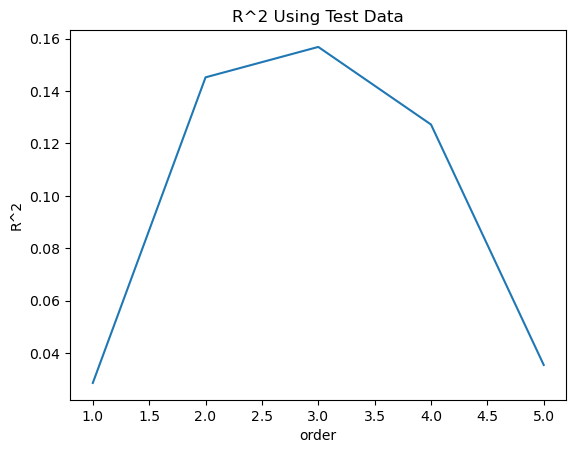

In [34]:
lr=LinearRegression()


Rsqu_test = []

order = [1, 2, 3, 4,5]
for n in order:
    pr = PolynomialFeatures(degree=n)
    
    x_train_pr = pr.fit_transform(x_train[['CPU_frequency']])
    
    x_test_pr = pr.fit_transform(x_test[['CPU_frequency']])    
    
    lr.fit(x_train_pr, y_train)
    
    Rsqu_test.append(lr.score(x_test_pr, y_test))

plt.plot(order, Rsqu_test)
plt.xlabel('order')
plt.ylabel('R^2')
plt.title('R^2 Using Test Data')
# plt.text(3, 0.75, 'Maximum R^2 ')   
plt.show()

In [35]:
pr=PolynomialFeatures(degree=2)
x_train_pr=pr.fit_transform(x_train[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU']])
x_test_pr=pr.fit_transform(x_test[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU']])


In [37]:

Rsqu_test = []
Rsqu_train = []
dummy1 = []
Alpha = np.arange(0.001,1,0.001)
pbar = tqdm(Alpha)

for alpha in pbar:
    RigeModel = Ridge(alpha=alpha) 
    RigeModel.fit(x_train_pr, y_train)
    test_score, train_score = RigeModel.score(x_test_pr, y_test), RigeModel.score(x_train_pr, y_train)
    
    pbar.set_postfix({"Test Score": test_score, "Train Score": train_score})

    Rsqu_test.append(test_score)
    Rsqu_train.append(train_score)

100%|███████████████████████████████████████████| 999/999 [00:05<00:00, 196.68it/s, Test Score=0.39, Train Score=0.587]


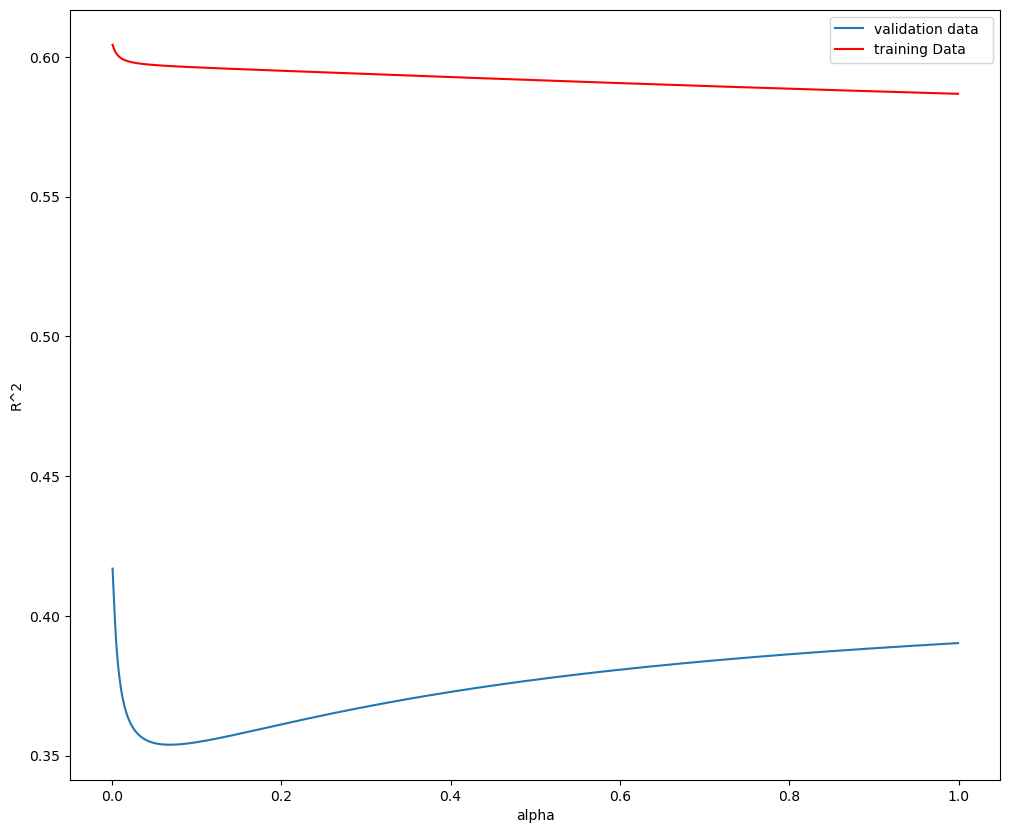

In [38]:
width = 12
height = 10
plt.figure(figsize=(width, height))

plt.plot(Alpha,Rsqu_test, label='validation data  ')
plt.plot(Alpha,Rsqu_train, 'r', label='training Data ')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.legend()
plt.show()

In [41]:
parameters1= [{'alpha': [0.001,0.001,0.1,1, 10]}]
parameters1


[{'alpha': [0.001, 0.001, 0.1, 1, 10]}]

In [ ]:
BestRR=Grid1.best_estimator_
BestRRb

In [42]:
RR=Ridge()
RR


Ridge()

In [44]:
Grid1 = GridSearchCV(RR, parameters1,cv=4)

Grid1.fit(x_data[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU']], y_data)

GridSearchCV(cv=4, estimator=Ridge(),
             param_grid=[{'alpha': [0.001, 0.001, 0.1, 1, 10]}])

In [46]:
BestRR=Grid1.best_estimator_
BestRR

Ridge(alpha=0.001)